In [30]:
import subprocess
from PIL import Image
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

# Constants

In [8]:
COGO_SRC_PATH = "/home/elissa/ADFA/CodeOnTheGo"
ANDROID_SDK_DIR = "/home/elissa/ADFA/png_optimization/androidsdk"
OUTPUT_DIR = "compressed"

In [9]:
IMAGES_LIST = []

In [10]:
MODE_TO_BPP = {'1':1, 'L':8, 'P':8, 'RGB':24, 'RGBA':32, 'CMYK':32, 'YCbCr':24, 'I':32, 'F':32, 'LA': 16}

# Assemble list of image files

In [11]:
def get_images(abs_paths):
    images = []
    
    for path in abs_paths:
        # Running a command and capturing its output
        find_result = subprocess.run(['find', path, "-name", "*.png"], capture_output=True, text=True)
        
        find_stdout_img_list = find_result.stdout.split("\n")[:-1]
        print(path + " -- " + str(len(find_stdout_img_list)) + " images")
        
        images += find_stdout_img_list

    return images

In [12]:
IMAGES_LIST = get_images([COGO_SRC_PATH, ANDROID_SDK_DIR])
IMAGES_LIST = [f.strip() for f in IMAGES_LIST]
open("image_list.txt", "w").write("\n".join(IMAGES_LIST))

/home/elissa/ADFA/CodeOnTheGo -- 135 images
/home/elissa/ADFA/png_optimization/androidsdk -- 6266 images


777147

In [13]:
data = []
for image_file in IMAGES_LIST:
    with Image.open(image_file) as img:
        width, height = img.size
        depth = img.mode
        bpp = MODE_TO_BPP[depth]
        file_size = os.path.getsize(image_file)

        data.append({
            'image_file': image_file,
            'width': width,
            'height': height,
            'depth': depth,
            'bpp': bpp,
            'size': file_size
        })
            
image_df = pd.DataFrame(data)

In [14]:
image_compressed_map = {}

for idx, f in enumerate(IMAGES_LIST):
    new_file_name = os.path.join(OUTPUT_DIR, f.replace("/", "_"))

    image_compressed_map[new_file_name] = f
    
    compress_result = subprocess.run(['pngquant', f, "-o", new_file_name], capture_output=True, text=True)

    if idx % 100 == 0:
        print(compress_result.stdout)
        print(compress_result.stderr)

In [39]:
compressed_data = []
for image_file in image_compressed_map.keys():
    with Image.open(image_file) as img:
        width, height = img.size
        depth = img.mode
        file_size = os.path.getsize(image_file)
        bpp = MODE_TO_BPP[depth]

        compressed_data.append({
            'image_file': image_file,
            'width': width,
            'height': height,
            'depth': depth,
            'bpp': bpp,
            'size': file_size
        })
            
compressed_df = pd.DataFrame(compressed_data)

In [16]:
compressed_df.depth.value_counts()

depth
P    6401
Name: count, dtype: int64

In [17]:
compressed_df["depth"].value_counts()

depth
P    6401
Name: count, dtype: int64

In [18]:
def get_color_counts(image_list, conv=False):
    results = {}
    for image in image_list:
        with Image.open(image) as img:
            if conv:
                img = img.convert("RGB")
            pixel_data = list(img.getdata())
            color_counts = {}
            for pixel_color in pixel_data:
                color_counts[pixel_color] = color_counts.get(pixel_color, 0) + 1
        results[image] = color_counts

    return results

In [19]:
d = get_color_counts(image_compressed_map.keys())

In [21]:
total_unique_colors = {}
for img, counts in d.items():
    color_count = len(set(counts.keys()))
    total_unique_colors[img] = color_count

In [32]:
colors_hist_list = [x[1] for x in total_unique_colors.items() if x[1] <= 6000]
outliers_list = [x for x in total_unique_colors.items() if x[1] > 6000]

max_colors = max(colors_hist_list)
print(max_colors)

256


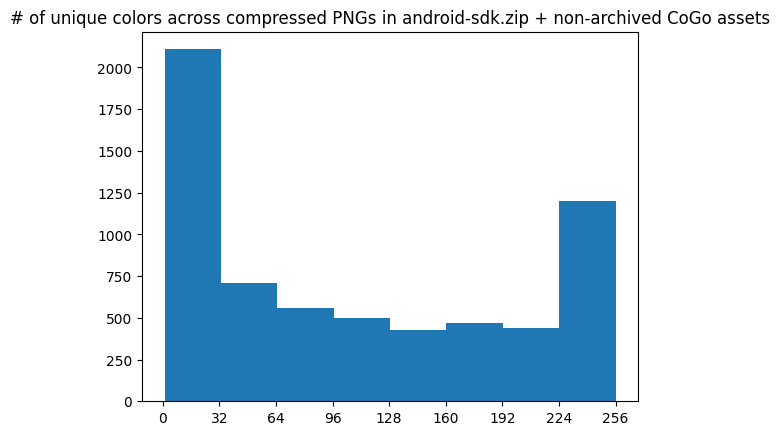

In [44]:
bin_count = 8
# max_colors = max(total_unique_colors.values())
plt.xticks([int(i * max_colors/bin_count) for i in range(bin_count + 1)])
plt.hist(colors_hist_list, bins=8)
plt.title("# of unique colors across compressed PNGs in android-sdk.zip + non-archived CoGo assets")
plt.savefig("unique_colors_comp.png")

In [42]:
compressed_df["bpp"]

0       8
1       8
2       8
3       8
4       8
       ..
6396    8
6397    8
6398    8
6399    8
6400    8
Name: bpp, Length: 6401, dtype: int64

In [43]:
bpp_count_dict = compressed_df["bpp"].value_counts().to_dict()
items = sorted(bpp_count_dict.items(), key=lambda x:x[0])
print(items)

[(8, 6401)]


In [133]:
f = "/home/elissa/ADFA/png_optimization/compressed/compressed/_home_elissa_ADFA_CodeOnTheGo_LayoutEditor_app_build_intermediates_packaged_res_v7Debug_packageV7DebugResources_drawable-v24_app_banner.png"
pixel_data = list(Image.open(f).getdata())
color_counts = {}
for pixel_color in pixel_data:
    color_counts[pixel_color] = color_counts.get(pixel_color, 0) + 1

print(len(color_counts.keys()))

251


In [31]:
orig_color_counts_norgbconv = get_color_counts(IMAGES_LIST)
#orig_color_counts_conv = get_color_counts(IMAGES_LIST, conv=True)

In [32]:
total_unique_colors = {}
for img, counts in orig_color_counts_norgbconv.items():
    color_count = len(set(counts.keys()))
    total_unique_colors[img] = color_count

In [50]:
# Cutoff above 6000
colors_hist_list = [x[1] for x in total_unique_colors.items() if x[1] <= 6000]
outliers_list = [x for x in total_unique_colors.items() if x[1] > 6000]

In [52]:
for filename, count in outliers_list:
    print(filename + "\t" + str(count))

/home/elissa/ADFA/png_optimization/androidsdk/skins/automotive_1024/fore.png	22892
/home/elissa/ADFA/png_optimization/androidsdk/skins/tv_4k/back.png	10638
/home/elissa/ADFA/png_optimization/androidsdk/platforms/android-33/data/res/drawable-sw720dp-nodpi/default_wallpaper.png	59201
/home/elissa/ADFA/png_optimization/androidsdk/platforms/android-33/data/res/drawable-sw600dp-hdpi/unlock_wave.png	15302
/home/elissa/ADFA/png_optimization/androidsdk/platforms/android-33/data/res/drawable-sw600dp-xhdpi/unlock_wave.png	18627
/home/elissa/ADFA/png_optimization/androidsdk/platforms/android-33/data/res/drawable-nodpi/default_wallpaper.png	20026
/home/elissa/ADFA/png_optimization/androidsdk/platforms/android-33/data/res/drawable-sw600dp-nodpi/default_wallpaper.png	43003
/home/elissa/ADFA/png_optimization/androidsdk/platforms/android-33/data/res/drawable-sw600dp-mdpi/unlock_wave.png	11318


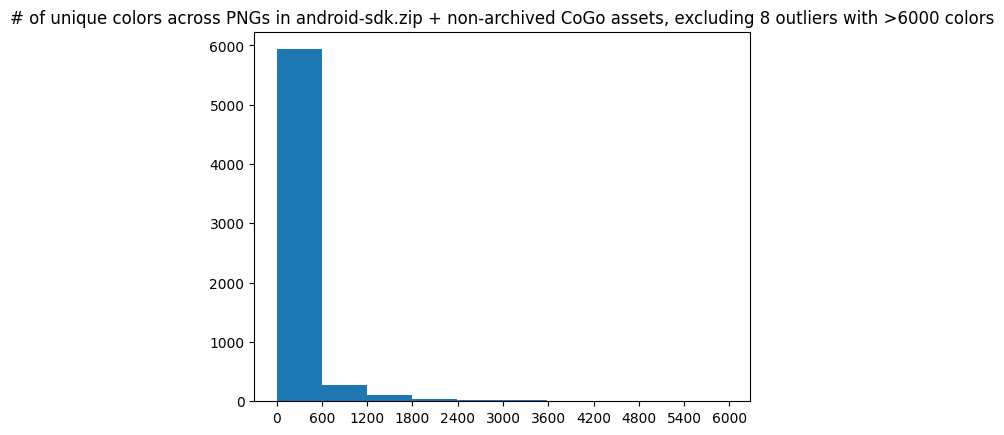

In [57]:
bin_count = 10
# max_colors = max(total_unique_colors.values())
plt.xticks([int(i * 6000/bin_count) for i in range(bin_count + 1)])
plt.hist(colors_hist_list, bins=10)
plt.title("# of unique colors across PNGs in android-sdk.zip + non-archived CoGo assets, excluding 8 outliers with >6000 colors")
plt.savefig("unique_colors.png")

In [39]:
out = "file\tuniq_colors\n"
f = open("color_counts_norgcbonv.txt", "w")
for image in orig_color_counts.keys():
    image_count_str = image + "\t" + str(len(orig_color_counts_norgbconv[image].keys()))
    out += image_count_str + "\n"

f.write(out)

out = "file\tuniq_colors\n"
f = open("color_counts_rgbconv.txt", "w")
for image in orig_color_counts.keys():
    image_count_str = image + "\t" + str(len(orig_color_counts_conv[image].keys()))
    out += image_count_str + "\n"

NameError: name 'orig_color_counts' is not defined

In [13]:
# https://www.libpng.org/pub/png/book/chapter08.html#:~:text=RGB%20(truecolor)%20PNGs%2C%20like%20grayscale%20with%20alpha%2C,to%2024%20and%2048%20bits%20per%20pixel.&text=As%20with%20RGB%20and%20gray+alpha%2C%20PNG%20supports,32%20and%2064%20bits%20per%20pixel%2C%20respectively.
# --> bit depth of alpha channel matches bit depth of grayscale channel
#
# https://pillow.readthedocs.io/en/stable/handbook/concepts.html
# --> "L" mode has a bit depth of 8
#
# LA = 16 bits per pixel
mode_to_bpp = {'1':1, 'L':8, 'P':8, 'RGB':24, 'RGBA':32, 'CMYK':32, 'YCbCr':24, 'I':32, 'F':32, 'LA': 16}

image_df["depth_bits"] = image_df["depth"].apply(lambda x:mode_to_bpp[x])

In [58]:
image_df["depth"].value_counts()

depth
RGBA    4576
LA      1096
P        664
RGB       47
L         18
Name: count, dtype: int64

In [41]:
bpp_count_dict = image_df["depth_bits"].value_counts().to_dict()
items = sorted(bpp_count_dict.items(), key=lambda x:x[0])
print(items)

KeyError: 'depth_bits'

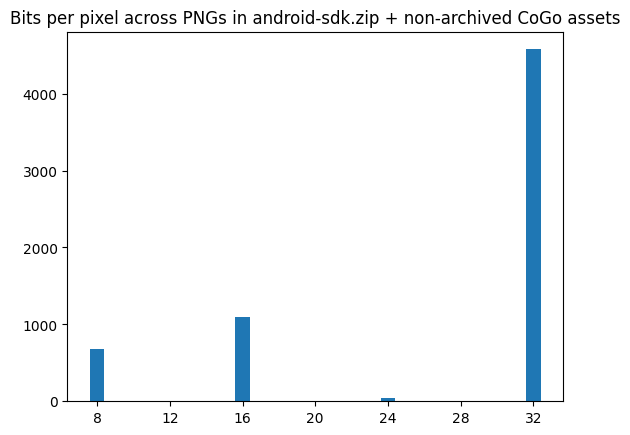

In [56]:

#plt.xticks([4,8,12,16,20,24,28,32])
#plt.hist(image_df["depth_bits"], bins=[4,8,12,16,20,24,28,32])
plt.xticks([4,8,12,16,20,24,28,32])
plt.bar([x[0] for x in items], [x[1] for x in items])
plt.title("Bits per pixel across PNGs in android-sdk.zip + non-archived CoGo assets")
plt.savefig("barchart_depths.png")